In [1]:
from pathlib import Path
import pandas as pd
import json

import sys
sys.path.append("../../utils/")

from utils import *

/home/javier/.conda/envs/tfgClean/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===== RUTAS =====
PROJECT_ROOT = Path.cwd().resolve().parents[2]

NOMBRE_DATASET_ENTRADA = "BCCC17__cleanning__v1"
NOMBRE_SPLIT = "BCCC17__split__v1"

RUTA_DATASET_LIMPIO = PROJECT_ROOT / "02_datasets" / "processed" / NOMBRE_DATASET_ENTRADA
RUTA_SALIDA = PROJECT_ROOT / "02_datasets" / "processed" / NOMBRE_SPLIT

NOMBRE_DATASET_LIMPIO = f"{NOMBRE_DATASET_ENTRADA}.csv"
NOMBRE_TRAIN = f"{NOMBRE_SPLIT}__train.csv"
NOMBRE_TEST = f"{NOMBRE_SPLIT}__test.csv"

NOMBRE_REPORTE = f"{NOMBRE_SPLIT}_report.json"
RUTA_REPORTE = PROJECT_ROOT / "04_experimentos" / "logs" / "resultados" / NOMBRE_SPLIT

# ===== PARÁMETROS =====
LABEL_COL = "LABEL"
TEST_SIZE = 0.20
RANDOM_STATE = 42

In [3]:
print("PROJECT_ROOT:")
print(PROJECT_ROOT)
print()

print("Dataset limpio de entrada:")
print(RUTA_DATASET_LIMPIO / NOMBRE_DATASET_LIMPIO)
print()

print("Ruta de salida:")
print(RUTA_SALIDA)

PROJECT_ROOT:
/home/javier/TFG_MODELOS_SIMPLES2

Dataset limpio de entrada:
/home/javier/TFG_MODELOS_SIMPLES2/02_datasets/processed/BCCC17__cleanning__v1/BCCC17__cleanning__v1.csv

Ruta de salida:
/home/javier/TFG_MODELOS_SIMPLES2/02_datasets/processed/BCCC17__split__v1


In [4]:
input_path = RUTA_DATASET_LIMPIO / NOMBRE_DATASET_LIMPIO

if not input_path.exists():
    raise FileNotFoundError(f"No existe el dataset limpio en: {input_path}")

df = cargar_dataset(nombre_dataset=NOMBRE_DATASET_LIMPIO, ruta_base=RUTA_DATASET_LIMPIO)

shape_original = df.shape

print("Forma del dataset limpio:")
print(shape_original)

Forma del dataset limpio:
(2363699, 64)


In [5]:
df.head()

,DST_PORT,PROTOCOL,DURATION,PACKETS_COUNT,FWD_TOTAL_PAYLOAD_BYTES,PAYLOAD_BYTES_MAX,PAYLOAD_BYTES_MIN,PAYLOAD_BYTES_MEAN,PAYLOAD_BYTES_VARIANCE,FWD_PAYLOAD_BYTES_VARIANCE,...,BWD_SYN_FLAG_COUNTS,BWD_CWR_FLAG_COUNTS,BWD_RST_FLAG_COUNTS,PACKETS_IAT_MEAN,FWD_PACKETS_IAT_MEAN,FWD_PACKETS_IAT_STD,BWD_PACKETS_IAT_MEAN,SUBFLOW_FWD_PACKETS,SUBFLOW_FWD_BYTES,LABEL
0,8080,0,0.135358,8,194,194,0,40.25,5132.4375,7056.75,...,1,0,0,0.019337,0.044937,0.062157,0.044844,0.0,0.0,8
1,8080,0,0.128585,8,194,194,0,40.25,5132.4375,7056.75,...,1,0,0,0.018369,0.042594,0.058929,0.042638,0.0,0.0,8
2,8080,0,0.166355,10,194,194,0,32.50,4346.6500,6021.76,...,1,0,0,0.018484,0.041452,0.071034,0.041467,0.0,0.0,8
3,8080,0,0.065549,8,1858,1858,0,248.25,371940.4375,647280.75,...,1,0,0,0.009364,0.021678,0.030040,0.021602,0.0,0.0,8
4,8080,0,0.080872,8,194,194,0,40.25,5132.4375,7056.75,...,1,0,0,0.011553,0.026702,0.037218,0.026761,0.0,0.0,8


In [6]:
if LABEL_COL not in df.columns:
    raise ValueError(f"No se encontró la columna {LABEL_COL}")

print("Columna objetivo encontrada correctamente.")
print()
print("Distribución global de clases:")
display(resumen_clases(df, LABEL_COL))

Columna objetivo encontrada correctamente.

Distribución global de clases:


,count,percentage
LABEL,,
0,1715048,72.5578
1,346143,14.6441
2,161323,6.8250
3,95729,4.0500
4,9531,0.4032
5,8364,0.3539
6,6856,0.2901
7,5949,0.2517
8,5508,0.2330


In [7]:
train_df, test_df = dividir_train_test_stratified(
    df=df,
    label_col=LABEL_COL,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Forma train:", train_df.shape)
print("Forma test:", test_df.shape)

Forma train: (1890959, 64)
Forma test: (472740, 64)


In [8]:
print("Distribución de clases en TRAIN:")
display(resumen_clases(train_df, LABEL_COL))

Distribución de clases en TRAIN:


,count,percentage
LABEL,,
0,1372038,72.5578
1,276914,14.6441
2,129058,6.8250
3,76583,4.0500
4,7625,0.4032
5,6691,0.3538
6,5485,0.2901
7,4759,0.2517
8,4406,0.2330


In [9]:
print("Distribución de clases en TEST:")
display(resumen_clases(test_df, LABEL_COL))

Distribución de clases en TEST:


,count,percentage
LABEL,,
0,343010,72.5579
1,69229,14.6442
2,32265,6.8251
3,19146,4.0500
4,1906,0.4032
5,1673,0.3539
6,1371,0.2900
7,1190,0.2517
8,1102,0.2331


In [10]:
resumen_global = resumen_clases(df, LABEL_COL).rename(
    columns={"count": "global_count", "percentage": "global_percentage"}
)

resumen_train = resumen_clases(train_df, LABEL_COL).rename(
    columns={"count": "train_count", "percentage": "train_percentage"}
)

resumen_test = resumen_clases(test_df, LABEL_COL).rename(
    columns={"count": "test_count", "percentage": "test_percentage"}
)

comparacion = pd.concat([resumen_global, resumen_train, resumen_test], axis=1)

print("Comparación global / train / test:")
display(comparacion)

Comparación global / train / test:


,global_count,global_percentage,train_count,train_percentage,test_count,test_percentage
LABEL,,,,,,
0,1715048,72.5578,1372038,72.5578,343010,72.5579
1,346143,14.6441,276914,14.6441,69229,14.6442
2,161323,6.8250,129058,6.8250,32265,6.8251
3,95729,4.0500,76583,4.0500,19146,4.0500
4,9531,0.4032,7625,0.4032,1906,0.4032
5,8364,0.3539,6691,0.3538,1673,0.3539
6,6856,0.2901,5485,0.2901,1371,0.2900
7,5949,0.2517,4759,0.2517,1190,0.2517
8,5508,0.2330,4406,0.2330,1102,0.2331


In [11]:
guardar_dataset_csv(
    df=train_df,
    nombre_archivo=NOMBRE_TRAIN,
    ruta=RUTA_SALIDA
)

guardar_dataset_csv(
    df=test_df,
    nombre_archivo=NOMBRE_TEST,
    ruta=RUTA_SALIDA
)

print("Train guardado en:")
print(RUTA_SALIDA / NOMBRE_TRAIN)
print()
print("Test guardado en:")
print(RUTA_SALIDA / NOMBRE_TEST)

Train guardado en:
/home/javier/TFG_MODELOS_SIMPLES2/02_datasets/processed/BCCC17__split__v1/BCCC17__split__v1__train.csv

Test guardado en:
/home/javier/TFG_MODELOS_SIMPLES2/02_datasets/processed/BCCC17__split__v1/BCCC17__split__v1__test.csv


In [12]:
reporte_split = {
    "dataset_entrada": NOMBRE_DATASET_LIMPIO,
    "label_column": LABEL_COL,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "shape_global": {
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1])
    },
    "shape_train": {
        "rows": int(train_df.shape[0]),
        "cols": int(train_df.shape[1])
    },
    "shape_test": {
        "rows": int(test_df.shape[0]),
        "cols": int(test_df.shape[1])
    },
    "class_distribution_global": {
        str(k): int(v) for k, v in df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    },
    "class_distribution_train": {
        str(k): int(v) for k, v in train_df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    },
    "class_distribution_test": {
        str(k): int(v) for k, v in test_df[LABEL_COL].value_counts(dropna=False).to_dict().items()
    }
}

report_path = RUTA_REPORTE / NOMBRE_REPORTE

report_path.parent.mkdir(parents=True, exist_ok=True)

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(reporte_split, f, indent=2, ensure_ascii=False)

print("Reporte guardado en:")
print(report_path)

Reporte guardado en:
/home/javier/TFG_MODELOS_SIMPLES2/04_experimentos/logs/resultados/BCCC17__split__v1/BCCC17__split__v1_report.json


In [13]:
print("========== RESUMEN SPLIT ==========")
print(f"Dataset de entrada: {NOMBRE_DATASET_LIMPIO}")
print(f"Forma global: {df.shape}")
print(f"Forma train: {train_df.shape}")
print(f"Forma test: {test_df.shape}")
print(f"Test size: {TEST_SIZE}")
print(f"Random state: {RANDOM_STATE}")
print("===================================")

========== RESUMEN SPLIT ==========
Dataset de entrada: BCCC17__cleanning__v1.csv
Forma global: (2363699, 64)
Forma train: (1890959, 64)
Forma test: (472740, 64)
Test size: 0.2
Random state: 42


In [14]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import pandas as pd

# ===== PCA: VARIABLES QUE FORMAN LAS 5 PRIMERAS COMPONENTES =====

X_train = train_df.drop(columns=[LABEL_COL])

# Solo variables numéricas
X_train_num = X_train.select_dtypes(include=["number"]).copy()

# Escalado SOLO con train
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

# PCA con 5 componentes
pca = PCA(n_components=5, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)

# Pesos/loadings de cada variable en cada componente
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train_num.columns,
    columns=[f"PC{i}" for i in range(1, 6)]
)

print("Pesos de cada variable en las 5 primeras componentes:")
display(loadings)

# Ver las variables más importantes por componente
for pc in loadings.columns:
    print(f"\n===== Variables más importantes en {pc} =====")
    display(
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(10)
        .to_frame(name=f"peso_abs_{pc}")
    )

Pesos de cada variable en las 5 primeras componentes:


,PC1,PC2,PC3,PC4,PC5
DST_PORT,2.478025e-07,-5.903741e-07,1.885850e-06,3.881746e-07,-6.154789e-06
PROTOCOL,-5.280037e-09,-1.083259e-08,-3.710293e-09,9.692495e-10,-5.191532e-07
DURATION,-6.607294e-07,-3.362307e-07,-3.126058e-06,5.850633e-07,1.362765e-04
PACKETS_COUNT,-3.487406e-08,6.991924e-08,-1.227413e-07,5.802775e-10,3.251773e-03
FWD_TOTAL_PAYLOAD_BYTES,-2.670309e-08,2.041674e-08,-7.954357e-08,3.387237e-07,1.615950e-05
...,...,...,...,...,...
FWD_PACKETS_IAT_MEAN,6.295566e-09,-8.601101e-09,2.292086e-08,-1.340746e-09,-1.532686e-07
FWD_PACKETS_IAT_STD,-4.620138e-07,-2.268556e-07,-2.187274e-06,5.495013e-07,4.040485e-06
BWD_PACKETS_IAT_MEAN,2.227134e-02,-2.300632e-01,9.728822e-01,8.665262e-03,1.291057e-04
SUBFLOW_FWD_PACKETS,-4.040904e-08,5.977573e-08,-1.582771e-07,2.836093e-08,3.451864e-03



===== Variables más importantes en PC1 =====


,peso_abs_PC1
PACKETS_IAT_MEAN,0.999025
AVG_BWD_BULK_RATE,0.038067
BWD_PACKETS_IAT_MEAN,0.022271
AVG_FWD_BULK_RATE,0.001862
AVG_BWD_BYTES_PER_BULK,0.000040
FWD_BYTES_RATE,0.000002
SUBFLOW_FWD_BYTES,0.000002
FWD_BULK_TOTAL_SIZE,0.000002
AVG_FWD_BYTES_PER_BULK,0.000001
FWD_PACKETS_RATE,0.000001



===== Variables más importantes en PC2 =====


...

,peso_abs_PC3
BWD_PACKETS_IAT_MEAN,0.972882
AVG_BWD_BULK_RATE,0.230775
PACKETS_IAT_MEAN,0.012911
AVG_FWD_BULK_RATE,0.008729
AVG_BWD_BYTES_PER_BULK,0.000067
FWD_BYTES_RATE,0.000014
FWD_PACKETS_RATE,0.000010
SUBFLOW_FWD_BYTES,0.000008
PACKETS_RATE,0.000006
FWD_PAYLOAD_BYTES_VARIANCE,0.000004



===== Variables más importantes en PC4 =====


,peso_abs_PC4
AVG_FWD_BULK_RATE,0.999960
BWD_PACKETS_IAT_MEAN,0.008665
PACKETS_IAT_MEAN,0.001724
AVG_BWD_BULK_RATE,0.001390
FWD_BYTES_RATE,0.000225
FWD_BULK_TOTAL_SIZE,0.000092
AVG_FWD_BYTES_PER_BULK,0.000084
BYTES_RATE,0.000046
FWD_PACKETS_RATE,0.000031
FWD_PAYLOAD_BYTES_VARIANCE,0.000026



===== Variables más importantes en PC5 =====


,peso_abs_PC5
AVG_BWD_BYTES_PER_BULK,0.999988
SUBFLOW_FWD_PACKETS,0.003452
PACKETS_COUNT,0.003252
SUBFLOW_FWD_BYTES,0.000994
FWD_BULK_TOTAL_SIZE,0.000272
AVG_BWD_BULK_RATE,0.000252
PSH_FLAG_COUNTS,0.000159
DURATION,0.000136
FWD_BYTES_RATE,0.000133
BWD_PACKETS_IAT_MEAN,0.000129


Shape X_train numérico: (1890959, 63)


K para 95.0% de varianza: 2


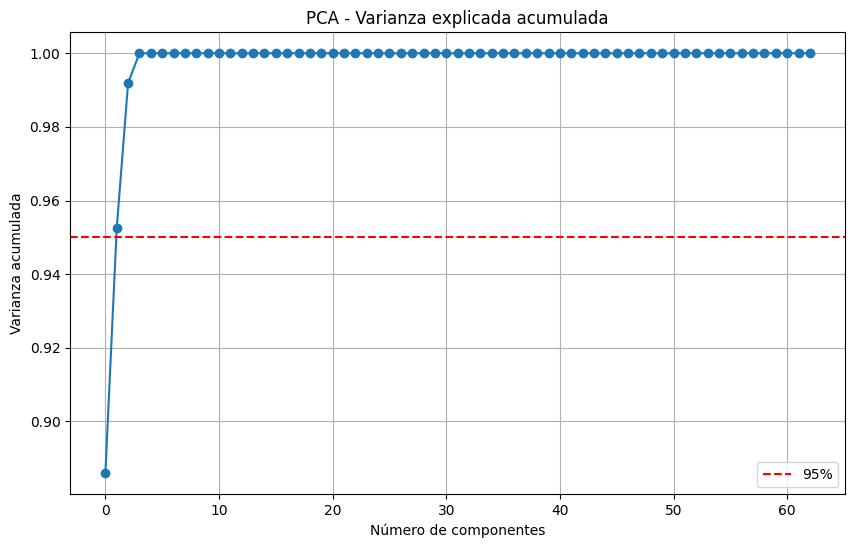

In [15]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# ===== PCA VARIANZA ACUMULADA (SOLO TRAIN) =====

# Separar X
X_train = train_df.drop(columns=[LABEL_COL])

# Solo numéricas
X_train_num = X_train.select_dtypes(include=["number"]).copy()

print("Shape X_train numérico:", X_train_num.shape)

# Escalado
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_num)

# PCA sin limitar componentes (para analizar)
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train_scaled)

# Varianza
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Threshold (puedes cambiarlo si quieres)
VARIANCE_THRESHOLD = 0.95

k = np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1

print(f"K para {VARIANCE_THRESHOLD*100}% de varianza:", k)

# ===== PLOT =====
plt.figure(figsize=(10, 6))

plt.plot(cumulative_variance, marker='o')
plt.axhline(y=VARIANCE_THRESHOLD, color='r', linestyle='--', label=f'{int(VARIANCE_THRESHOLD*100)}%')

plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("PCA - Varianza explicada acumulada")
plt.grid(True)
plt.legend()

plt.show()

In [16]:
from sklearn.preprocessing import RobustScaler, RobustScaler
from sklearn.decomposition import PCA
import numpy as np

def calcular_k(scaler, X, threshold=0.95):
    X_scaled = scaler.fit_transform(X)
    pca = PCA().fit(X_scaled)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    return np.argmax(cum_var >= threshold) + 1

k_standard = calcular_k(RobustScaler(), X_train_num)
k_robust = calcular_k(RobustScaler(), X_train_num)

print("K con RobustScaler:", k_standard)
print("K con RobustScaler:", k_robust)

K con RobustScaler: 2
K con RobustScaler: 2
